# Operaciones con SymPy y Graficación de Transiciones con NetworkX

A continuación, se presenta una guía rapida sobre cómo manejar cálculos algebraicos exactos usando la librería SymPy de Python

A diferencia de otras herramientas que usan aproximación de decimales, SymPy trabaja de forma simbolica (es decir, lo hace como si fueramos nosotros trabjando a papel y lapiz), esto ayuda a no perder precisión en cálculos pesados.

El contenido que se encontrara en este documento serán ejemplos prácticos de:
* Multiplicación de vectores con matrices
* Potencias de matrices
* Solución de sistemas de ecuaciones lineales
* Cálculo exacto de valores y vectores propios
* Cálculo del estado estacionario

Además, integraremos NetworkX para:
* Trazar diagramas de transición de estados a partir de una matriz


## ¿Qué necesitamos?

Para poder trabajar del modo en que desarrollaremos a lo largo del trabajo necestiamos 3 cosas:
* **Sympy**
  
  Es una librería que nos permite definir variables simbolicas, fracciones exactas y operar matrices matematicamente. Sera escencial para nuestro trabajo

* **NetworkX**

  Es una librería que nos permite crear, manipular y estudiar la estructura de grafos y redes complejas

* **Matplotllib**

  La usaremos para crear apoyos visuales que NetworkX usará para dibujar grafos


### Instalación de librerias

(Este paso solo es necesario en la primera vez que creas tu notebook)

Como primer paso instalaremos la librerias:

In [ ]:
!pip install sympy
!pip install networkx
!pip install matplotlib

O bien las puedes ponere todas en una linea, pero para mejor estructura y control de tu codigo, yo recomiendo separarlo.

### Importación de librerías

Acoplamos las librerias instaladas a nuestro proyecto, dandoles un nombre con el que las llamaremos cada vez que las ocupemos.

Esto se realiza de la siguiente forma:

In [10]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

Tambien activaremos el renderizado matemático de la siguiente forma:

In [11]:
sp.init_printing(use_latex='mathjax')

## 1) Multiplicación de Vectores con Matrices

En SymPy, las matrices se crean pasando una lista de listas al objeto sp.Matrix. 

Para mantener la precisión matemática, es súper recomendable usar sp.Rational en lugar de escribir decimales directamente (por ejemplo, **sp.Rational(1, 3)** en vez de 0.333).

Definimos a los vectores simplemente como una matriz de una sola fila o columna 

In [14]:
#Matriz de transición (usando fracciones exactas)
P = sp.Matrix([
    [sp.Rational(1, 2), sp.Rational(1, 2)], 
    [sp.Rational(1, 4), sp.Rational(3, 4)]
])

#Vector de estado inicial (matriz de 1x2)
v0 = sp.Matrix([[1, 0]]) 

#La multiplicación se hace directamente con el operador *
v1 = v0 * P

print("Matriz P:")
display(P)
print("Estado después de una transición (v0 * P):")
display(v1)

Matriz P:


⎡1/2  1/2⎤
⎢        ⎥
⎣1/4  3/4⎦

Estado después de una transición (v0 * P):


[1/2  1/2]

## 2) Potencias de Matrices y Solución de Sistemas

Elevar una matriz a la enésima potencia nos ayuda a proyectar el comportamiento del sistema a futuro. En SymPy basta con usar **.
    
Para resolver sistemas de la forma $Ax = b$ (muy útil para buscar el estado estacionario de una matriz de transición), SymPy tiene el **método .solve()**, que maneja desde sistemas determinados hasta paramétricos.

In [15]:
#Proyectar a 3 pasos (P al cubo)
P_3 = P**3

## Solución de un sistema lineal ##

#Queremos resolver el sistema Ax = b
A = sp.Matrix([[3, 2], [1, -1]])
b = sp.Matrix([7, 4]) # Vector columna

#Encontramos x
x = A.solve(b)

print("Matriz de transición a 3 pasos:")
display(P_3)
print("Solución al sistema Ax=b (vector x):")
display(x)

Matriz de transición a 3 pasos:


⎡11  21⎤
⎢──  ──⎥
⎢32  32⎥
⎢      ⎥
⎢21  43⎥
⎢──  ──⎥
⎣64  64⎦

Solución al sistema Ax=b (vector x):


⎡3 ⎤
⎢  ⎥
⎣-1⎦

## 3) Cálculo de Valores y Vectores Propios

El análisis espectral nos dice cómo se comporta la matriz en su base original.

* **.eigenvals():** Devuelve un diccionario donde la llave es el eigenvalor y el valor es su multiplicidad algebraica.

* **.eigenvects():** Devuelve una lista detallada con la estructura (eigenvalor, multiplicidad, [eigenvectores]).

In [16]:
#Obtenemos los valores propios
valores_propios = P.eigenvals()

#Obtenemos los vectores propios
vectores_propios = P.eigenvects()

print("Valores propios {valor: multiplicidad}:")
display(valores_propios)
print("Vectores propios:")
display(vectores_propios)

Valores propios {valor: multiplicidad}:


{1/4: 1, 1: 1}

Vectores propios:


⎡⎛        ⎡⎡-2⎤⎤⎞  ⎛      ⎡⎡1⎤⎤⎞⎤
⎢⎜1/4, 1, ⎢⎢  ⎥⎥⎟, ⎜1, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝        ⎣⎣1 ⎦⎦⎠  ⎝      ⎣⎣1⎦⎦⎠⎦

## 4) Diagramas de Transición con NetworkX

Para representar visualmente los estados de una matriz, usamos la clase **DiGraph** (Grafo Dirigido) de NetworkX. 

La idea esencial es agregar "nodos" (nuestros estados) y "aristas" (las flechas) que tienen un atributo de peso (la probabilidad)

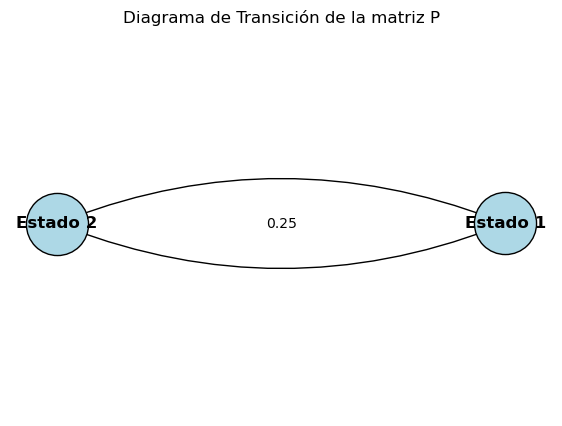

In [17]:
# 1.-Inicializamos el grafo dirigido
G = nx.DiGraph()

# 2.-Definimos las conexiones (origen, destino, peso/probabilidad)
# Fíjate que estos datos reflejan la matriz P de arriba
conexiones = [
    ("Estado 1", "Estado 1", 0.5),
    ("Estado 1", "Estado 2", 0.5),
    ("Estado 2", "Estado 1", 0.25),
    ("Estado 2", "Estado 2", 0.75)
]

# 3.-Agregamos las aristas al grafo
for origen, destino, peso in conexiones:
    G.add_edge(origen, destino, weight=peso)

# 4.-Dibujamos el grafo
plt.figure(figsize=(7, 5))

#Esta función acomoda los nodos en un círculo para que se vea ordenado
posicion = nx.circular_layout(G)

#Dibujamos las partes del grafo
nx.draw_networkx_nodes(G, posicion, node_color='lightblue', edgecolors='black', node_size=2000)
nx.draw_networkx_labels(G, posicion, font_weight='bold')
nx.draw_networkx_edges(G, posicion, arrowstyle='->', arrowsize=25, connectionstyle='arc3,rad=0.2')

#Sacamos los pesos y los ponemos como etiquetas en las flechas
etiquetas_pesos = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posicion, edge_labels=etiquetas_pesos)

plt.title("Diagrama de Transición de la matriz P")
# Quitamos los ejes del plano cartesiano
plt.axis('off')

plt.show()

## 5) Cálculo del Estado Estacionario

Como cierre del tutorial, podemos usar lo aprendido para hallar el estado estacionario de la matriz $P$. 

Matemáticamente, buscamos un vector $\pi$ tal que $\pi P = \pi$. Esto se resuelve despejando el sistema $(\mathbf{P}^T - \mathbf{I})\mathbf{\pi} = 0$, añadiendo la condición de que la suma de las probabilidades sea igual a 1.

In [18]:
#Definimos variables simbólicas para las probabilidades del estado estacionario
pi1, pi2 = sp.symbols('pi1 pi2')
pi = sp.Matrix([[pi1, pi2]])

#Creamos el sistema: pi * P = pi  =>  pi * (P - I) = 0
I = sp.eye(2) # Matriz identidad
sistema = pi * (P - I)

#Añadimos la condición de normalización (pi1 + pi2 = 1)
ecuaciones = [sistema[0], sistema[1], pi1 + pi2 - 1]

#Resolvemos el sistema
estado_estable = sp.solve(ecuaciones, (pi1, pi2))

print("Estado Estacionario (punto de equilibrio del sistema):")
display(estado_estable)

Estado Estacionario (punto de equilibrio del sistema):


{π₁: 1/3, π₂: 2/3}